#  MuJoCo Bootcamp : Control a double pendulum

---- 

- conda env : [ai_robotics](../../../README.md#setup-a-conda-environment)

---

### Reference : 
- https://pab47.github.io/mujoco.html
- https://youtu.be/HYVPysAGp6g

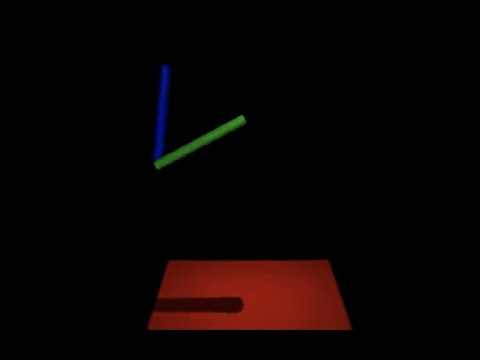

In [1]:
from IPython.display import YouTubeVideo

YouTubeVideo('HYVPysAGp6g')

## Run python code

In [ ]:
!python double_pendulum.py

## Jupyter code

### Load XML file and build model and data

In [1]:
import mujoco as mj
import numpy as np
import mediapy as media

# Create an XML file string for a simple ball on a plane
xml_path = "./doublependulum.xml" 

# MuJoCo data structures
model = mj.MjModel.from_xml_path(xml_path)
data = mj.MjData(model)

### Setup the controller

In [2]:
def controller(model, data):
    """
    This function implements a Feedback Linearization controller
    """
    # Evaluate position-dependent energy (potential).
    mj.mj_energyPos(model, data)

    # Evaluate velocity-dependent energy (kinetic).
    mj.mj_energyVel(model, data)

    # Convert sparse inertia matrix M into full (i.e. dense) matrix.
    # M is filled with the data from data.qM
    M = np.zeros((2, 2))
    mj.mj_fullM(model, M, data.qM)

    # Defines PD gain and reference angles
    Kp = 100 * np.eye(2)
    Kd = 10 * np.eye(2)
    qref = np.array([[-0.5], [-1.6]])

    # f compensates Coriolis and gravitational forces
    f = data.qfrc_bias[:, np.newaxis]

    # τ = M * ddqref
    ddqref = Kp @ (qref - data.qpos[:2][:, np.newaxis]) + \
        Kd @ (0 - data.qvel[:2][:, np.newaxis])
    tau = M @ ddqref

    data.qfrc_applied = (tau + f)[:, 0]

#set the controller
mj.set_mjcb_control(controller)

### Setup the configuration of render

In [3]:
# Offscreen rendering setup
width, height = 200, 200
renderer = mj.Renderer(model, width, height)

# Set camera configuration
cam = mj.MjvCamera()
mj.mjv_defaultCamera(cam)
# Set camera configuration
cam.azimuth = 89.608063
cam.elevation = -11.588379
cam.distance = 5.0
cam.lookat = np.array([0.0, 0.0, 2.0])

### Initialization 

In [4]:
# Reset the data to initial state
mj.mj_resetData(model, data)

#set initial conditions
data.qpos[0] = 0.1

### Simulation

In [5]:
# Store frames for visualization
frames = []
framerate = 60
simend = 5

while data.time < simend:
    # Perform a single simulation step
    simstart = data.time

    while (data.time - simstart < 1.0/60.0):
        mj.mj_step(model, data)
    
    # Render the scene from the specified camera
    renderer.update_scene(data, camera=cam)
    
    # Get the rendered RGB image and store it
    rgb_image = renderer.render()
    frames.append(rgb_image)

media.show_video(frames, fps=framerate)




This browser does not support the video tag.
